In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"D:\datasets\owid-covid-data.csv")

In [3]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [4]:
df.shape

(429435, 67)

In [5]:
df.columns

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

### Data Cleaning

In [7]:
# checking null values
df.isnull().sum()[ df.isnull().sum() > 0]

continent                                   26525
total_cases                                 17631
new_cases                                   19276
new_cases_smoothed                          20506
total_deaths                                17631
                                            ...  
human_development_index                    110308
excess_mortality_cumulative_absolute       416024
excess_mortality_cumulative                416024
excess_mortality                           416024
excess_mortality_cumulative_per_million    416024
Length: 63, dtype: int64

In [8]:
# missing values in percentage
df.isnull().mean().sort_values(ascending = False) * 100

weekly_icu_admissions                   97.440125
weekly_icu_admissions_per_million       97.440125
excess_mortality                        96.877059
excess_mortality_cumulative_absolute    96.877059
excess_mortality_cumulative             96.877059
                                          ...    
total_cases_per_million                  4.105627
location                                 0.000000
iso_code                                 0.000000
date                                     0.000000
population                               0.000000
Length: 67, dtype: float64

In [9]:
missing_percentage = df.isnull().mean() * 100

columns_to_drop = missing_percentage[missing_percentage > 70].index
columns_to_drop

Index(['icu_patients', 'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'total_vaccinations_per_hundred',
       'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred',
       'total_boosters_per_hundred', 'excess_mortality_cumulative_absolute',
       'excess_mortality_cumulative', 'excess_mortality',
       'excess_mortality_cumulative_per_million'],
      dtype='object')

In [10]:
df = df.drop(columns = columns_to_drop )

In [11]:
df.shape

(429435, 37)

In [12]:
df.isnull().mean().sort_values(ascending = False) * 100

handwashing_facilities                        62.336326
reproduction_rate                             56.962753
new_people_vaccinated_smoothed                55.248874
new_people_vaccinated_smoothed_per_hundred    55.248874
new_vaccinations_smoothed                     54.584745
new_vaccinations_smoothed_per_million         54.584745
stringency_index                              54.314390
extreme_poverty                               50.633740
male_smokers                                  43.223771
female_smokers                                42.444142
hospital_beds_per_thousand                    32.308964
human_development_index                       25.686774
aged_65_older                                 24.722018
gdp_per_capita                                23.552575
cardiovasc_death_rate                         23.419144
aged_70_older                                 22.848627
median_age                                    22.068998
diabetes_prevalence                           19

In [13]:
df = df.drop('handwashing_facilities', axis=1)

In [14]:
# filter post 2021 because vaccination starts 2021
df = df[df['date'] >= '2021-01-01']

In [15]:
# some contries have insufficient reporting 
# keep only those countries which have sufficient reporting
country_valid = df.groupby('location')['reproduction_rate']\
                   .apply(lambda x: x.notna().mean())\
                   .loc[lambda x: x > 0.4].index

df = df[df['location'].isin(country_valid)]

In [16]:
# fill missing days using previous value (forward fill)
df[['reproduction_rate','stringency_index']] = \
df.groupby('location')[['reproduction_rate','stringency_index']].ffill()

In [17]:
df.isnull().mean().sort_values(ascending = False) * 100

new_people_vaccinated_smoothed_per_hundred    37.458585
new_people_vaccinated_smoothed                37.458585
new_vaccinations_smoothed                     36.447211
new_vaccinations_smoothed_per_million         36.447211
extreme_poverty                               34.150367
male_smokers                                  24.895400
female_smokers                                23.807312
hospital_beds_per_thousand                    10.750258
stringency_index                               8.164806
aged_65_older                                  4.765775
aged_70_older                                  4.352351
median_age                                     3.808307
gdp_per_capita                                 3.677687
cardiovasc_death_rate                          2.720220
human_development_index                        2.589599
population_density                             1.501511
diabetes_prevalence                            1.501511
new_cases                                      1

In [18]:
# drop the columns which are not required
df = df.drop(['extreme_poverty','male_smokers','female_smokers'], axis=1)

In [19]:
df['hospital_beds_per_thousand'] = \
df.groupby('location')['hospital_beds_per_thousand'].ffill()

In [20]:
df[['new_vaccinations_smoothed']] = df[['new_vaccinations_smoothed']].fillna(0)

In [21]:
df['stringency_index'] = \
df.groupby('location')['stringency_index'].ffill()

In [22]:
static_cols = ['gdp_per_capita','human_development_index',
               'aged_65_older','median_age','life_expectancy']

df[static_cols] = df.groupby('location')[static_cols].ffill()

In [23]:
df.isnull().mean().sort_values(ascending = False) * 100

new_people_vaccinated_smoothed                37.458585
new_people_vaccinated_smoothed_per_hundred    37.458585
new_vaccinations_smoothed_per_million         36.447211
hospital_beds_per_thousand                    10.750258
stringency_index                               8.164806
aged_65_older                                  4.765775
aged_70_older                                  4.352351
median_age                                     3.808307
gdp_per_capita                                 3.677687
cardiovasc_death_rate                          2.720220
human_development_index                        2.589599
diabetes_prevalence                            1.501511
population_density                             1.501511
new_cases_smoothed_per_million                 1.117944
new_cases_smoothed                             1.117944
new_cases_per_million                          1.117944
new_cases                                      1.117944
new_deaths_smoothed_per_million                0

In [24]:
df = df[df['hospital_beds_per_thousand'].notna()]

In [25]:
df.isnull().mean().sort_values(ascending = False) * 100

new_people_vaccinated_smoothed                37.746246
new_people_vaccinated_smoothed_per_hundred    37.746246
new_vaccinations_smoothed_per_million         36.613050
stringency_index                               7.929118
aged_70_older                                  3.657449
aged_65_older                                  3.657449
median_age                                     3.047874
gdp_per_capita                                 3.047874
cardiovasc_death_rate                          2.438299
human_development_index                        1.828724
new_cases_per_million                          0.788916
new_cases_smoothed                             0.788916
new_cases                                      0.788916
new_cases_smoothed_per_million                 0.788916
continent                                      0.614221
population_density                             0.609575
diabetes_prevalence                            0.609575
new_deaths_smoothed_per_million                0

- The dataset contains missing values due to differences in country reporting and the timeline of vaccine rollout.
- Instead of over-imputing, I handled them contextually by forward-filling static indicators, filtering low-reporting entities, and preserving daily metrics to maintain real trend patterns.
- This ensured analytical accuracy while reflecting real-world data limitations.

In [26]:
df.shape

(215232, 33)

In [27]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,median_age,aged_65_older,aged_70_older,gdp_per_capita,cardiovasc_death_rate,diabetes_prevalence,hospital_beds_per_thousand,life_expectancy,human_development_index,population
362,AFG,Asia,Afghanistan,2021-01-01,51848.0,0.0,187.43,2158.0,0.0,14.86,...,18.6,2.58,1.34,1803.99,597.03,9.59,0.5,64.83,0.51,41128772
363,AFG,Asia,Afghanistan,2021-01-02,51848.0,0.0,187.43,2158.0,0.0,14.86,...,18.6,2.58,1.34,1803.99,597.03,9.59,0.5,64.83,0.51,41128772
364,AFG,Asia,Afghanistan,2021-01-03,52709.0,861.0,123.00,2221.0,63.0,9.00,...,18.6,2.58,1.34,1803.99,597.03,9.59,0.5,64.83,0.51,41128772
365,AFG,Asia,Afghanistan,2021-01-04,52709.0,0.0,123.00,2221.0,0.0,9.00,...,18.6,2.58,1.34,1803.99,597.03,9.59,0.5,64.83,0.51,41128772
366,AFG,Asia,Afghanistan,2021-01-05,52709.0,0.0,123.00,2221.0,0.0,9.00,...,18.6,2.58,1.34,1803.99,597.03,9.59,0.5,64.83,0.51,41128772


In [33]:
# create excel file for cleaned data
import zipfile

with zipfile.ZipFile("Covid_data.zip","w") as zipf:
    zipf.write("cleaned_covid_19_data.csv")

### Data Visualization

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

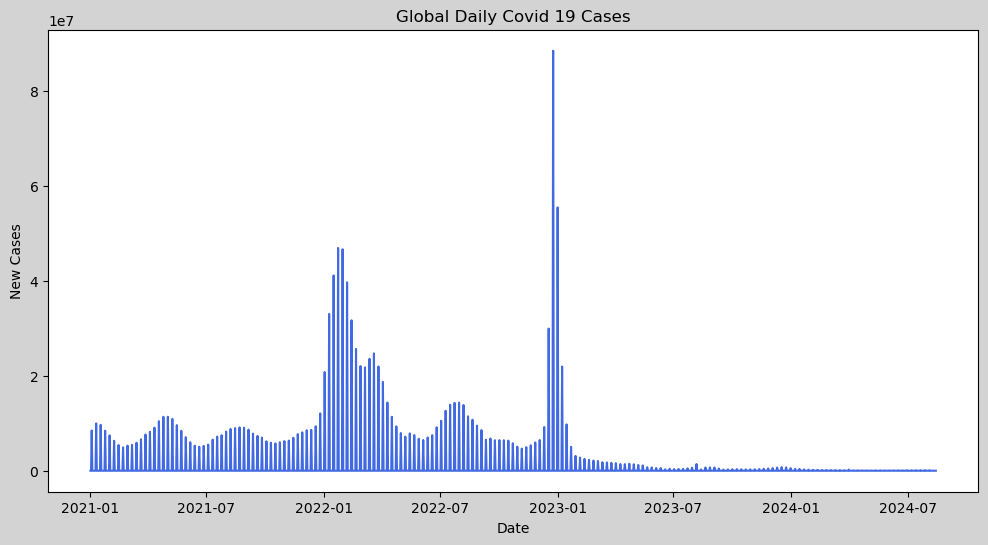

In [35]:
# global covid cases over time
df['date'] = pd.to_datetime(df['date'])
global_cases = df.groupby('date')['new_cases'].sum()

fig, ax = plt.subplots(figsize=(12,6))
fig.patch.set_facecolor("lightgrey")
ax.set_facecolor("white")

plt.plot(global_cases, color='royalblue')
plt.title("Global Daily Covid 19 Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

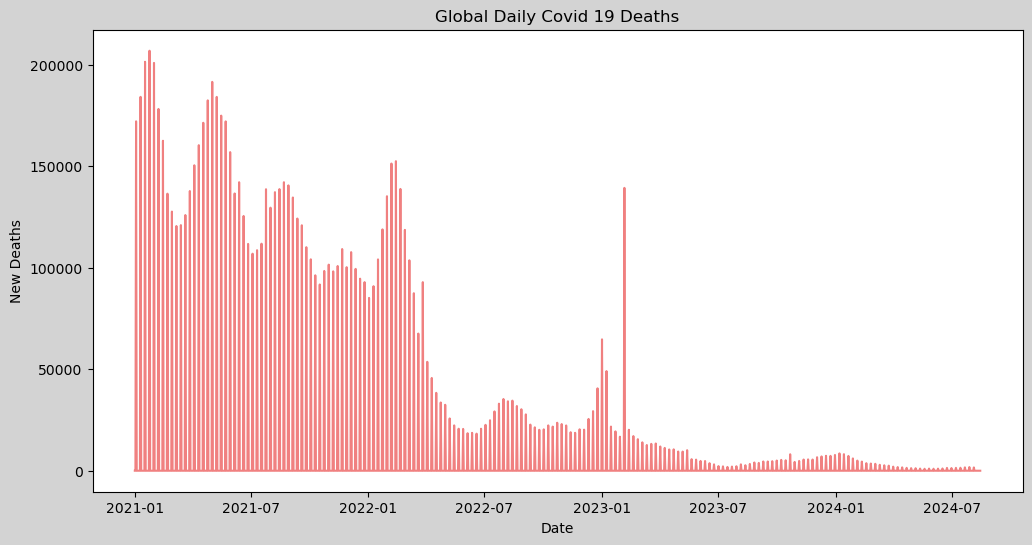

In [36]:
# global health trends
global_Deaths = df.groupby('date')['new_deaths'].sum()

fig, ax = plt.subplots(figsize=(12,6))
fig.patch.set_facecolor("lightgrey")
ax.set_facecolor("white")

plt.plot(global_Deaths, color='lightcoral')
plt.title("Global Daily Covid 19 Deaths")
plt.xlabel("Date")
plt.ylabel("New Deaths")
plt.show()

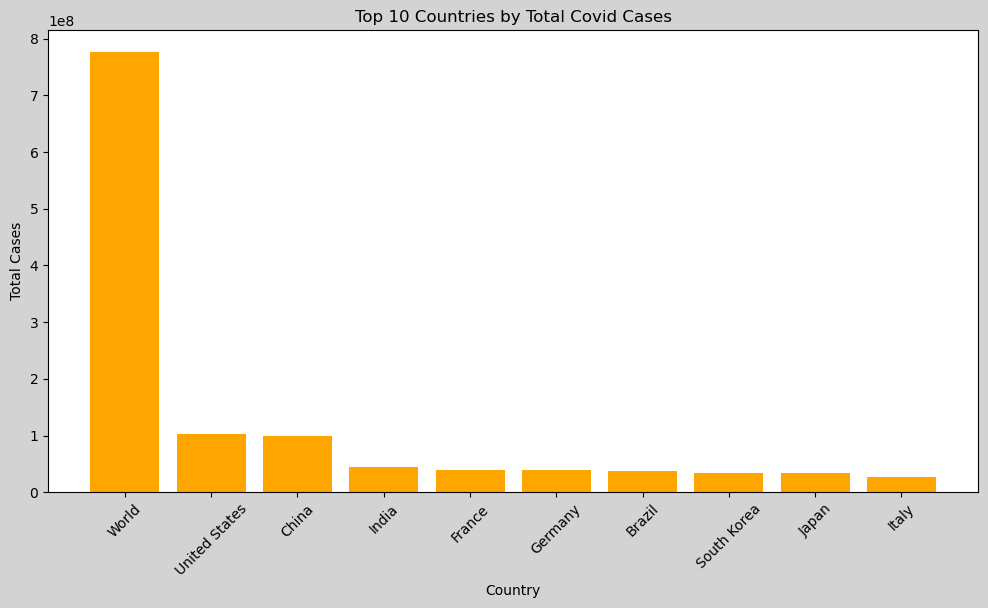

In [37]:
# top 10 countries by total cases
latest = df.sort_values('date').groupby('location').last()

top_cases = latest.sort_values('total_cases', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12,6))
fig.patch.set_facecolor("lightgrey")
ax.set_facecolor("white")

plt.bar(top_cases.index, top_cases['total_cases'], color='orange')
plt.xticks(rotation= 45)
plt.title("Top 10 Countries by Total Covid Cases")
plt.xlabel("Country")
plt.ylabel("Total Cases")
plt.show()

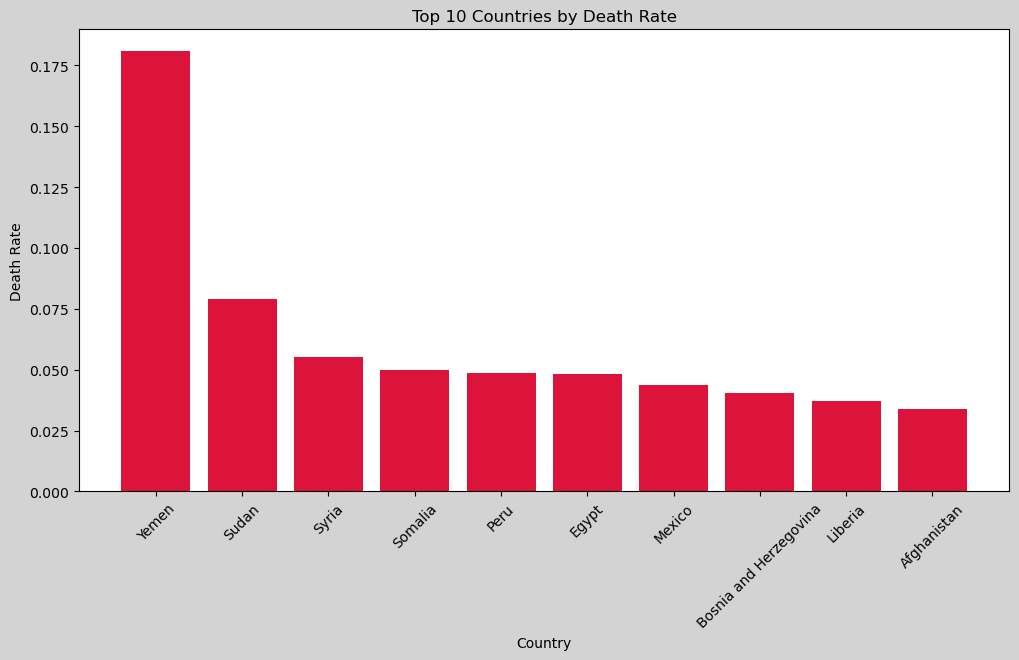

In [38]:
# top 10 countries by death rate
latest['death_rate']= latest['total_deaths'] / latest['total_cases']

top_death_rate = latest.sort_values('death_rate', ascending = False).head(10)

fig, ax = plt.subplots(figsize=(12,6))
fig.patch.set_facecolor("lightgrey")
ax.set_facecolor("white")

plt.bar(top_death_rate.index, top_death_rate['death_rate'], color = 'crimson')
plt.xticks(rotation= 45)
plt.title("Top 10 Countries by Death Rate")
plt.xlabel("Country")
plt.ylabel("Death Rate")
plt.show()

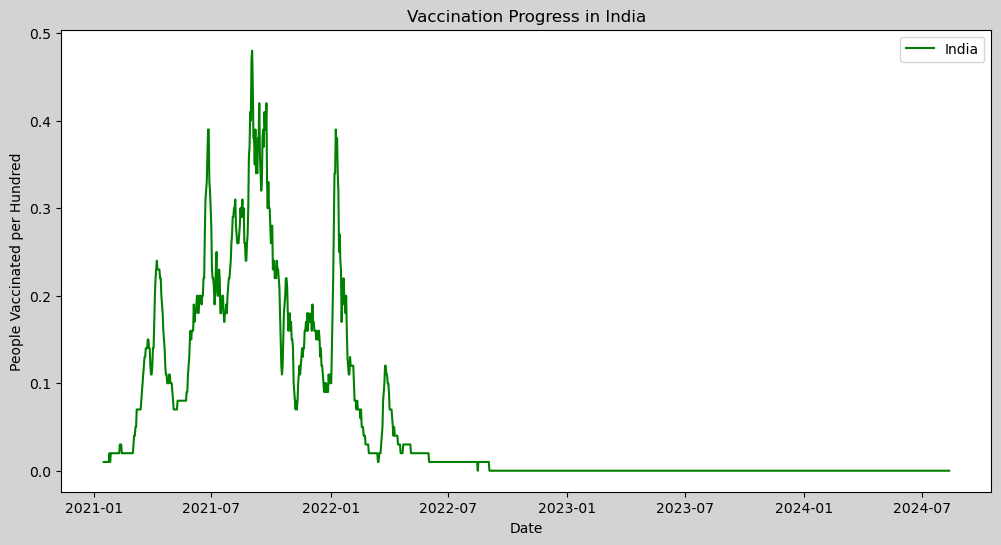

In [39]:
# Vaccination progress over time in India
countries = ['India']

fig, ax = plt.subplots(figsize=(12,6))
fig.patch.set_facecolor("lightgrey")
ax.set_facecolor("white")

for country in countries:
    data = df[df['location']==country]
    plt.plot(data['date'], data['new_people_vaccinated_smoothed_per_hundred'], label=country, color='green')

plt.legend()
plt.title("Vaccination Progress in India")
plt.xlabel("Date")
plt.ylabel("People Vaccinated per Hundred")
plt.show()

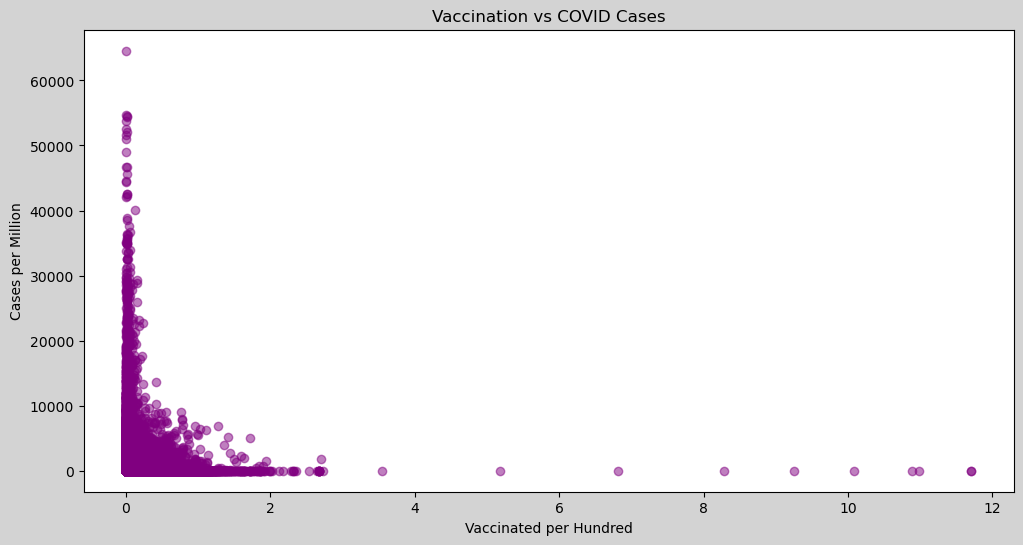

In [40]:
# vaccination vs Cases
fig, ax = plt.subplots(figsize=(12,6))
fig.patch.set_facecolor("lightgrey")
ax.set_facecolor("white")

plt.scatter(df['new_people_vaccinated_smoothed_per_hundred'],
            df['new_cases_per_million'], color='purple',
            alpha=0.5)

plt.title("Vaccination vs COVID Cases")
plt.xlabel("Vaccinated per Hundred")
plt.ylabel("Cases per Million")
plt.show()

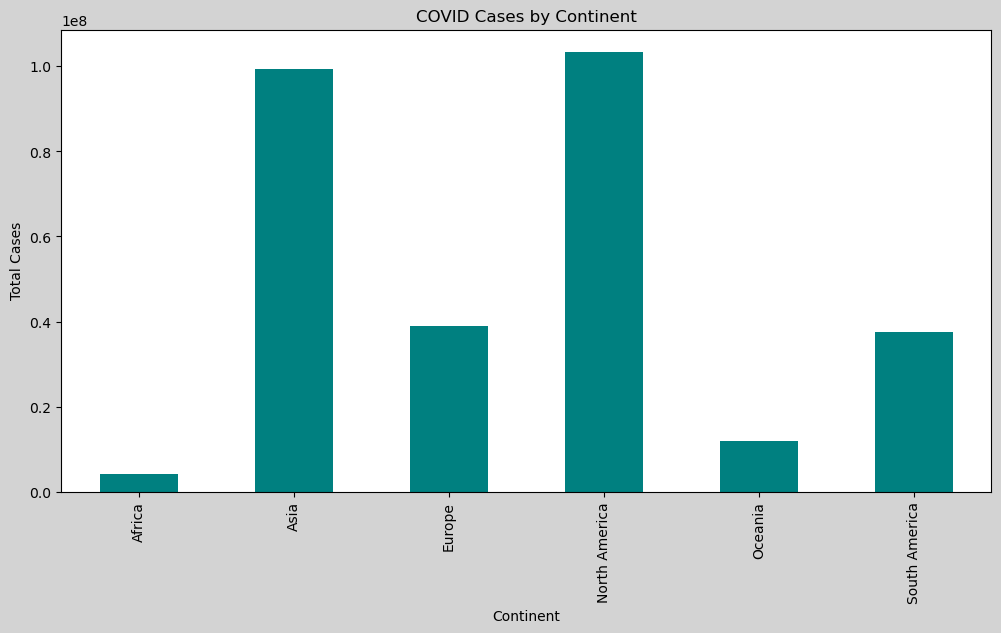

In [41]:
# Continent wise covid cases
continent_cases = df.groupby('continent')['total_cases'].max()

fig, ax = plt.subplots(figsize=(12,6))
fig.patch.set_facecolor("lightgrey")
ax.set_facecolor("white")

continent_cases.plot(kind='bar', color= 'teal')

plt.title("COVID Cases by Continent")
plt.xlabel("Continent")
plt.ylabel("Total Cases")
plt.show()

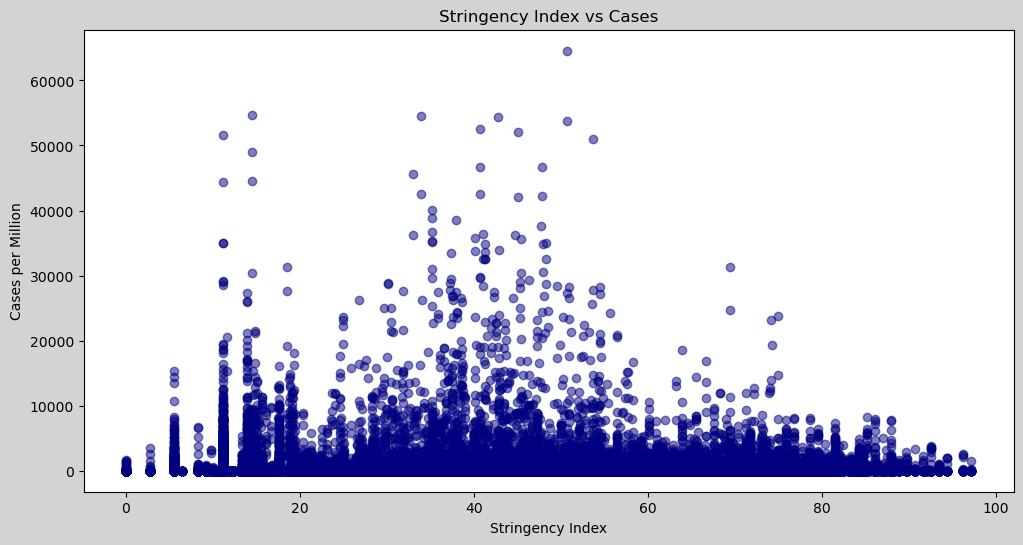

In [42]:
# Stringency Index vs Cases
fig, ax = plt.subplots(figsize=(12,6))
fig.patch.set_facecolor("lightgrey")
ax.set_facecolor("white")

plt.scatter(df['stringency_index'],
            df['new_cases_per_million'], color='navy',
            alpha=0.5)

plt.title("Stringency Index vs Cases")
plt.xlabel("Stringency Index")
plt.ylabel("Cases per Million")
plt.show()

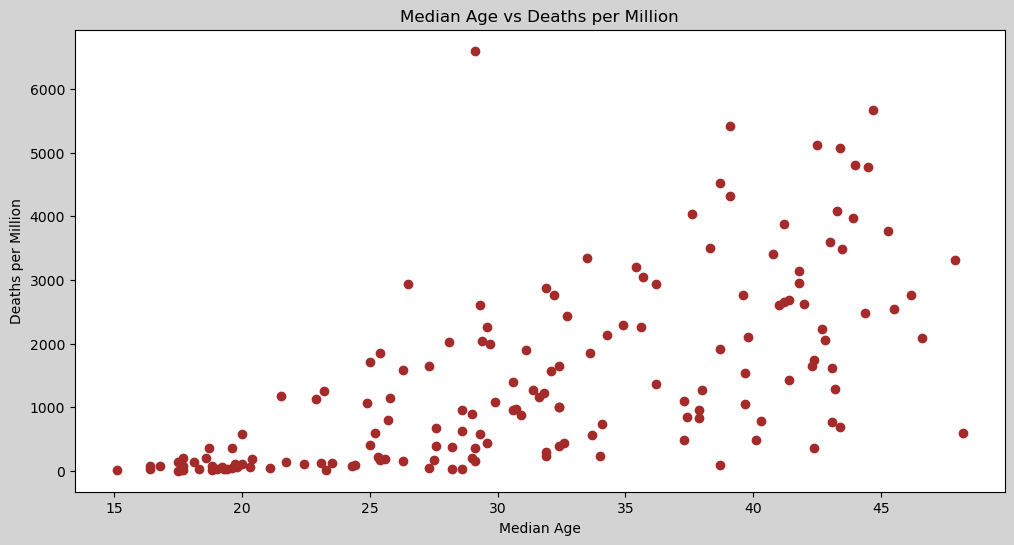

In [43]:
# median age vs death rate
latest['death_per_million'] = latest['total_deaths_per_million']

fig, ax = plt.subplots(figsize=(12,6))
fig.patch.set_facecolor("lightgrey")
ax.set_facecolor("white")

plt.scatter(latest['median_age'], latest['death_per_million'], color='brown')

plt.title("Median Age vs Deaths per Million")
plt.xlabel("Median Age")
plt.ylabel("Deaths per Million")
plt.show()

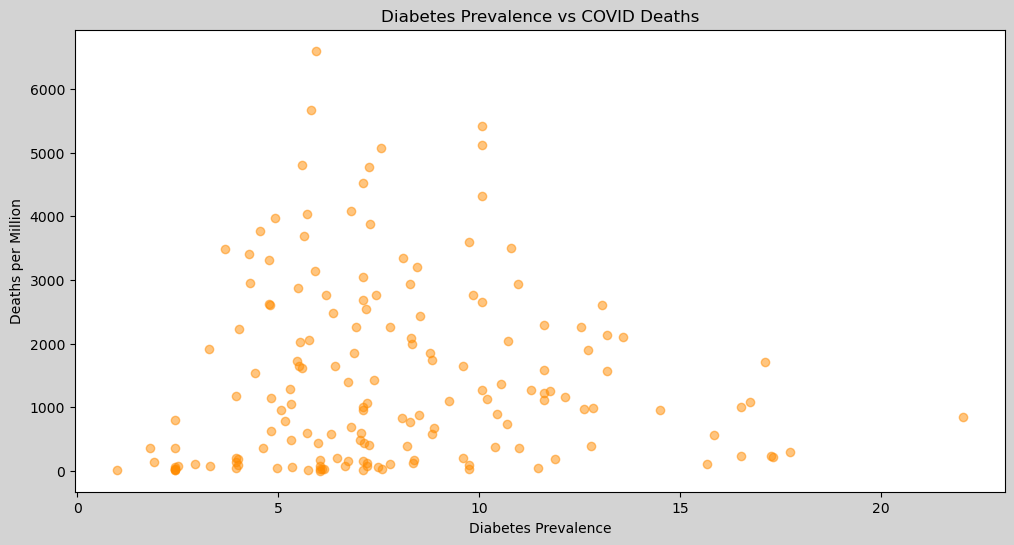

In [44]:
# health factors vs Covid deaths

fig, ax = plt.subplots(figsize=(12,6))
fig.patch.set_facecolor("lightgrey")
ax.set_facecolor("white")

plt.scatter(latest['diabetes_prevalence'],
            latest['total_deaths_per_million'], color= 'darkorange',
            alpha=0.5)

plt.title("Diabetes Prevalence vs COVID Deaths")
plt.xlabel("Diabetes Prevalence")
plt.ylabel("Deaths per Million")
plt.show()

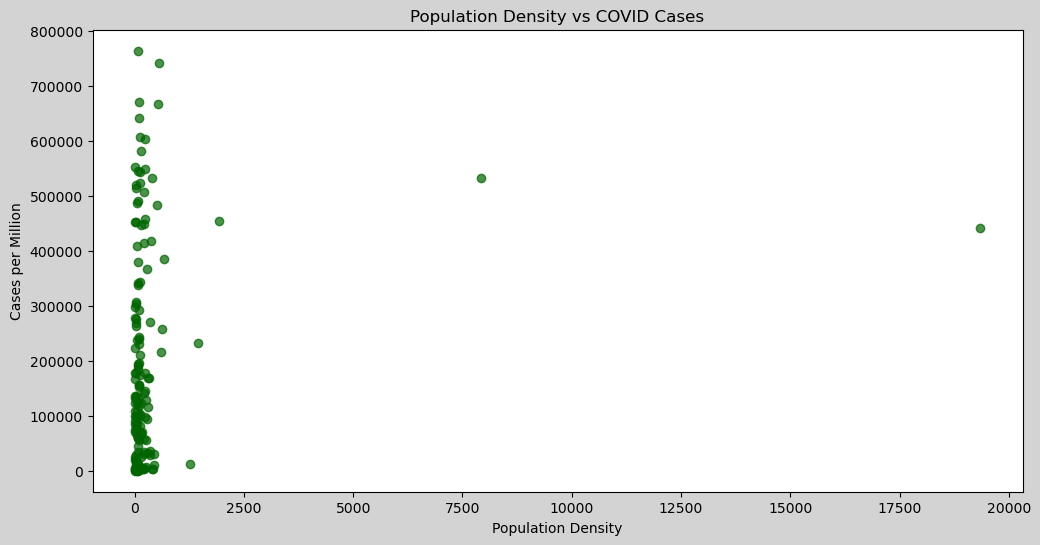

In [45]:
# Population Density  vs Cases
fig, ax = plt.subplots(figsize=(12,6))
fig.patch.set_facecolor("lightgrey")
ax.set_facecolor("white")

plt.scatter(latest['population_density'],
            latest['total_cases_per_million'], color= 'darkgreen',
            alpha=0.7)

plt.title("Population Density vs COVID Cases")
plt.xlabel("Population Density")
plt.ylabel("Cases per Million")
plt.show()

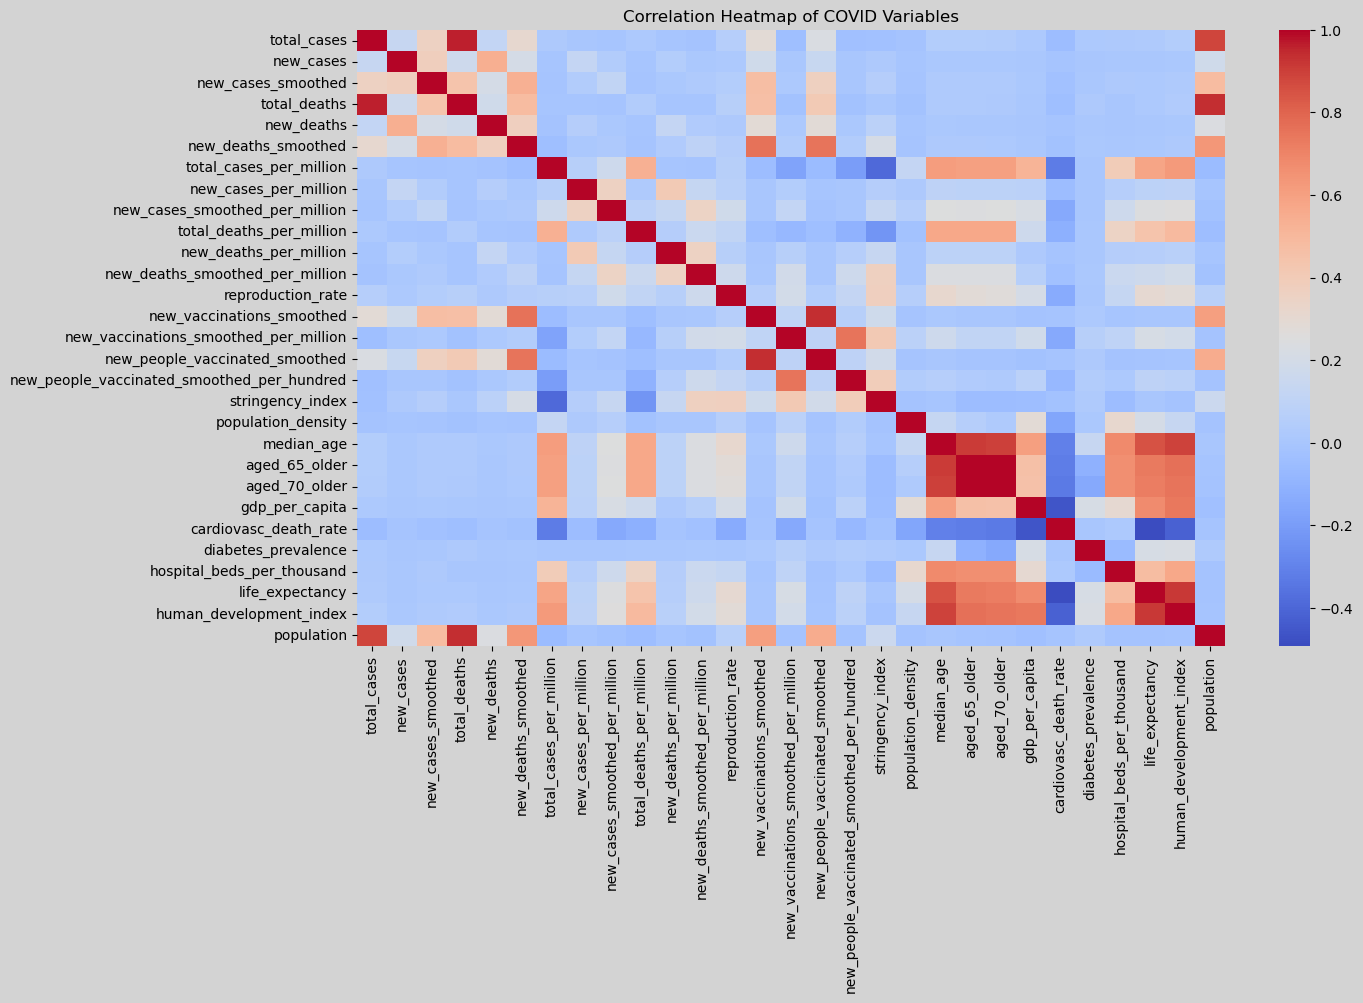

In [46]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=['float64','int64'])

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(14,8))
fig.patch.set_facecolor("lightgrey")
ax.set_facecolor("white")

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap of COVID Variables")
plt.show()

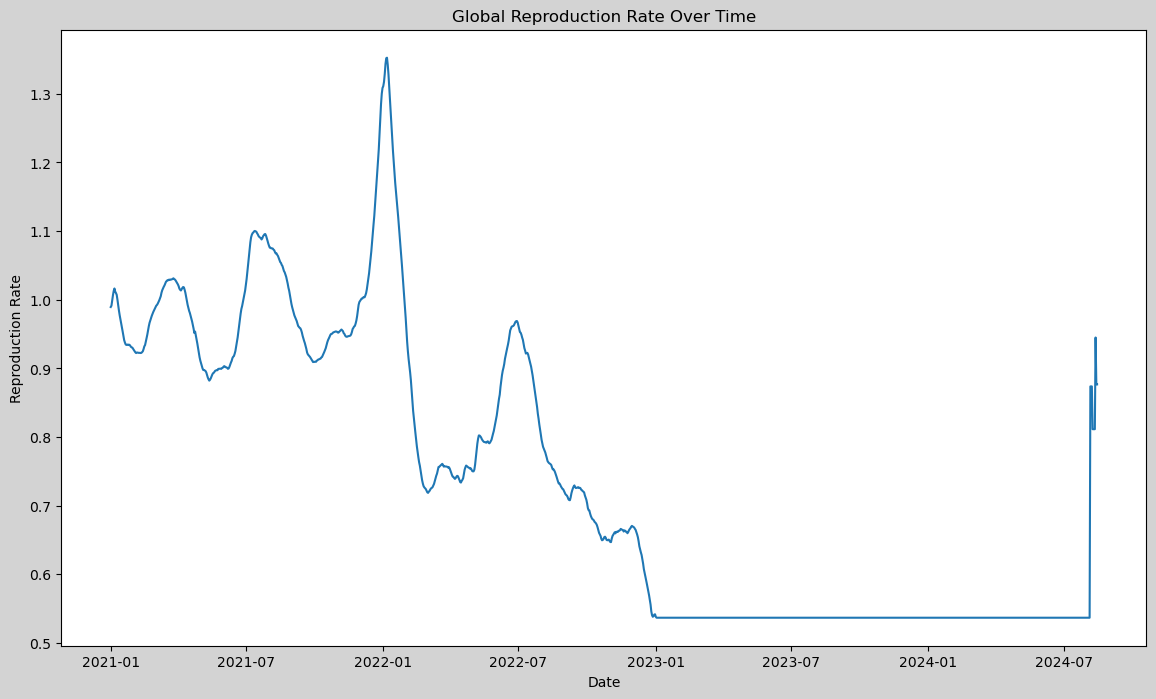

In [47]:
# Reproduction Rate Trend

global_r = df.groupby('date')['reproduction_rate'].mean()

fig, ax = plt.subplots(figsize=(14,8))
fig.patch.set_facecolor("lightgrey")
ax.set_facecolor("white")

plt.plot(global_r)

plt.title("Global Reproduction Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Reproduction Rate")
plt.show()

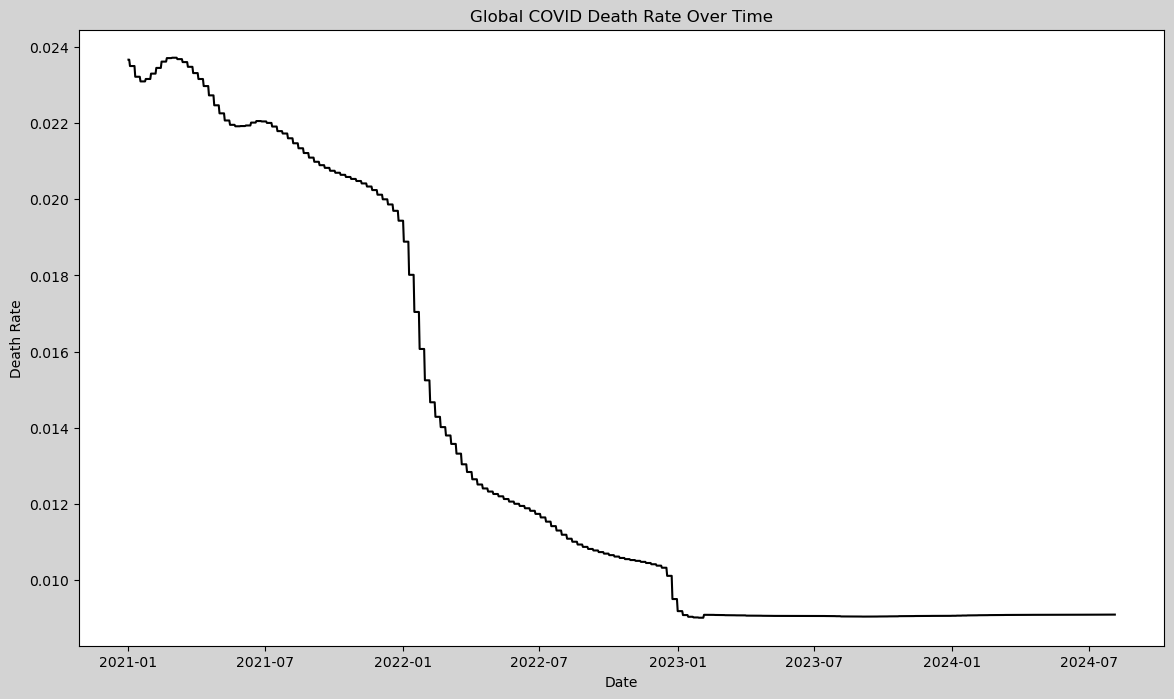

In [48]:
# global death rate trend
global_data = df.groupby('date')[['total_cases','total_deaths']].sum()

global_data['death_rate'] = global_data['total_deaths'] / global_data['total_cases']

fig, ax = plt.subplots(figsize=(14,8))
fig.patch.set_facecolor("lightgrey")
ax.set_facecolor("white")

plt.plot(global_data['death_rate'], color='black')

plt.title("Global COVID Death Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Death Rate")
plt.show()